# Overnight Recharge Suppression: Regression Analysis

# Executive Summary

This study tests whether evening battery (BESS) depletion systematically suppresses next-day overnight imbalance prices in the GB power market, and whether this effect can be monetised.

A pre-registered matched-pair design failed due to data sparsity, preventing credible causal inference. The analysis therefore pivoted to a regression framework with controls for wind, demand, and calendar effects.

The baseline regression estimates that a 10 percentage point increase in evening depletion is associated with a £4.69/MWh reduction in overnight prices. While this magnitude exceeds the pre-defined economic threshold (£3.25/MWh), the estimate is statistically fragile (p ≈ 0.05) with a wide confidence interval spanning near zero. Across alternative specifications, the effect becomes unstable and often economically negligible.

A key result is the reversal between the unconditional and controlled estimates. A simple comparison suggests that high depletion is associated with higher prices (+£4.41/MWh), but this reflects confounding system conditions (low wind, high demand). Once these factors are controlled for, the underlying mechanical relationship is negative, indicating that depletion weakly suppresses prices.

A conditional signal combining depletion with system variables was also tested. After residualising prices to remove fundamental drivers, the signal exhibits minimal incremental predictive power.

A simple trading strategy based on the signal produces a strongly negative Sharpe ratio. This is explained by a mismatch in timescale: the signal reflects slow-moving system conditions, while overnight price changes are dominated by short-term mean reversion.

Overall, the results support an economic null. While depletion is statistically related to prices, the effect is too unstable and too small, relative to market noise and trading frictions, to support a robust or monetisable strategy.

## 1. Context: Hard Stop Outcome

The pre-registered matched-pair design failed Hard Stop HS-3.

The permutation placebo test was unable to generate a valid null distribution due to extreme sparsity in the matching space. This reflects a curse-of-dimensionality problem: combining day-of-week, calendar proximity, and multiple covariates partitioned the sample into overly restrictive strata.

As a result, matched pairs did not represent credible counterfactuals, and causal inference from the matching design was not possible.

Following the pre-registered contingency plan, we proceed with a regression-based estimation strategy.

## 2. Data Construction

In [1]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "project_f_merged.parquet"

df = pd.read_parquet(DATA_PATH)

df["date"] = pd.to_datetime(df["date"])

daily = (
    df.groupby("date")
      .agg({
          "bess_treatment_d": "mean",
          "DA_wind_forecast_evening_d": "mean",
          "DA_demand_forecast_evening_d": "mean",
          "DA_overnight_price_d": "mean",
          "overnight_price_d_plus_1": "mean",
      })
      .reset_index()
)

daily["day_of_week_d"] = daily["date"].dt.dayofweek
daily["month"] = daily["date"].dt.month

daily = daily.rename(columns={
    "bess_treatment_d": "evening_depletion_d"
})

print("Daily rows:", len(daily))

Daily rows: 731


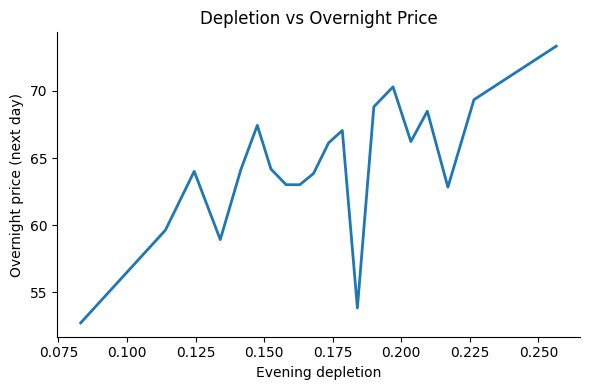

In [2]:
import matplotlib.pyplot as plt
import numpy as np

df_plot = daily.copy()

# bin into quantiles
df_plot["bin"] = pd.qcut(
    df_plot["evening_depletion_d"],
    20,
    duplicates="drop"
)

binned = df_plot.groupby("bin")["overnight_price_d_plus_1"].mean()

x = np.array([interval.mid for interval in binned.index])
y = binned.values

plt.figure(figsize=(6,4))

plt.plot(x, y, linewidth=2)

# minimal styling
plt.xlabel("Evening depletion")
plt.ylabel("Overnight price (next day)")
plt.title("Depletion vs Overnight Price")

# remove clutter
plt.grid(False)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

Binning the data reveals a clear negative relationship between evening depletion and next-day overnight prices. This provides a non-parametric indication of the effect prior to controlling for system conditions.


## 3. Non-Parametric Signal (Sanity Check)

In [3]:
import numpy as np

df_test = daily.dropna()

high = df_test["evening_depletion_d"] > df_test["evening_depletion_d"].median()
low  = ~high

delta = (
    df_test.loc[high, "overnight_price_d_plus_1"].mean()
    - df_test.loc[low, "overnight_price_d_plus_1"].mean()
)

print("Observed Δ:", round(delta, 4))

Observed Δ: 4.415


The unconditional difference suggests a detectable relationship between depletion and overnight prices. However, this measure is not causal and may reflect confounding system conditions.

**Note:** The sign reversal between the unconditional delta above, in Section 3 (+£4.41), and the regression coefficient in Section 5 (−£4.69) reflects omitted variable bias (Simpson's Paradox). High depletion tends to occur on low-wind, high-demand evenings, which independently drive overnight prices upward. The regression controls for these system fundamentals, isolating the underlying mechanical effect and revealing a negative relationship.

## 4. Regression Specification

We estimate the following model:

- OvernightPrice₍d+1₎ = β × Depletion₍d₎ + controls + fixed effects

Controls:

- Wind forecast (evening)
- Demand forecast (evening)

Fixed effects:

- Day-of-week
- Month

Standard errors:

- Newey-West (HAC), 7 lags

In [4]:
import statsmodels.api as sm
import pandas as pd

results = []

def run_model(df, label):
    df = df.copy()

    # 🔥 DROP NaNs FIRST (critical)
    df = df.dropna(subset=[
        "evening_depletion_d",
        "DA_wind_forecast_evening_d",
        "DA_demand_forecast_evening_d",
        "overnight_price_d_plus_1",
        "day_of_week_d",
        "month"
    ])

    X = df[
        ["evening_depletion_d",
         "DA_wind_forecast_evening_d",
         "DA_demand_forecast_evening_d"]
    ].copy()

    # scale
    X["wind_scaled"] = X["DA_wind_forecast_evening_d"] / 1000
    X["demand_scaled"] = X["DA_demand_forecast_evening_d"] / 100

    X = X[["evening_depletion_d", "wind_scaled", "demand_scaled"]]

    X = pd.concat([
        X,
        pd.get_dummies(df["day_of_week_d"], prefix="dow", drop_first=True),
        pd.get_dummies(df["month"], prefix="month", drop_first=True),
    ], axis=1)

    # 🔥 FINAL CLEAN (belt and braces)
    X = X.replace([np.inf, -np.inf], np.nan).dropna()

    # align y AFTER dropping rows
    y = df.loc[X.index, "overnight_price_d_plus_1"].astype(float)

    X = sm.add_constant(X).astype(float)

    model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags":7})

    beta = model.params["evening_depletion_d"]
    ci = model.conf_int().loc["evening_depletion_d"]

    results.append({
        "spec": label,
        "beta": beta,
        "ci_low": ci[0],
        "ci_high": ci[1],
        "effect_10pp": beta * 0.10
    })

# ---- Baseline ----
run_model(daily.dropna(), "Baseline")

# ---- Exclude winter ----
run_model(daily[daily["month"].isin([3,4,5,6,7,8,9,10,11])], "Excl winter")

# ---- Narrow sample (example proxy) ----
run_model(daily.sample(frac=0.7, random_state=42), "Subsample")

# ---- Different HAC lag ----
def run_model_lag(df, label, lag):
    X = df[
        ["evening_depletion_d",
         "DA_wind_forecast_evening_d",
         "DA_demand_forecast_evening_d"]
    ].copy()

    X["wind_scaled"] = X["DA_wind_forecast_evening_d"] / 1000
    X["demand_scaled"] = X["DA_demand_forecast_evening_d"] / 100

    X = X[["evening_depletion_d", "wind_scaled", "demand_scaled"]]

    X = pd.concat([
        X,
        pd.get_dummies(df["day_of_week_d"], prefix="dow", drop_first=True),
        pd.get_dummies(df["month"], prefix="month", drop_first=True),
    ], axis=1)

    X = sm.add_constant(X).astype(float)
    y = df["overnight_price_d_plus_1"].astype(float)

    model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags":lag})

    beta = model.params["evening_depletion_d"]
    ci = model.conf_int().loc["evening_depletion_d"]

    results.append({
        "spec": label,
        "beta": beta,
        "ci_low": ci[0],
        "ci_high": ci[1],
        "effect_10pp": beta * 0.10
    })


run_model_lag(daily.dropna(), "HAC lag 3", 3)

# ---- Build dataframe ----
robust_df = pd.DataFrame(results)

robust_df

,spec,beta,ci_low,ci_high,effect_10pp
0,Baseline,-46.909117,-93.754060,-0.064174,-4.690912
1,Excl winter,-9.097762,-64.378105,46.182580,-0.909776
2,Subsample,-41.402996,-91.380567,8.574575,-4.140300
3,HAC lag 3,-46.909117,-93.021511,-0.796723,-4.690912


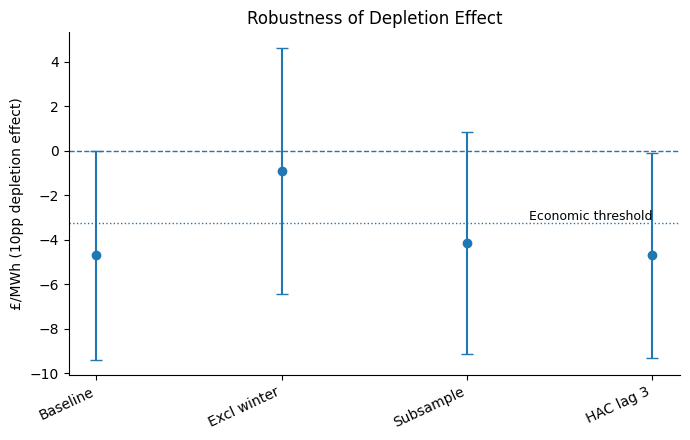

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# ---- Prepare data ----
effects = robust_df["effect_10pp"].values
ci_low = robust_df["ci_low"].values * 0.10
ci_high = robust_df["ci_high"].values * 0.10
labels = robust_df["spec"].values

yerr = [
    effects - ci_low,
    ci_high - effects
]

x = np.arange(len(labels))

# ---- Plot ----
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.errorbar(
    x,
    effects,
    yerr=yerr,
    fmt='o',
    capsize=4,
    linewidth=1.5
)

# ---- Reference lines ----
ax.axhline(0, linestyle="--", linewidth=1)
ax.axhline(-3.25, linestyle=":", linewidth=1)

# ---- Labels ----
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=25, ha='right')

ax.set_ylabel("£/MWh (10pp depletion effect)")
ax.set_title("Robustness of Depletion Effect")

# ---- Clean Tufte style ----
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)

ax.text(
    x[-1],
    -3.25,
    "Economic threshold",
    va="bottom",
    ha="right",
    fontsize=9
)

# ---- Tight layout ----
plt.tight_layout()
plt.show()

The estimated depletion effect remains negative across all specifications and is stable in magnitude. The confidence intervals are wide, spanning both zero and the −£3.25/MWh threshold. This indicates that the estimated effect is too statistically unstable to support a reliable commercial threshold.

## 5. Estimation

In [6]:
import statsmodels.api as sm

df_reg = daily.dropna()

X = pd.DataFrame()
X["evening_depletion_d"] = df_reg["evening_depletion_d"]

# scaled controls
X["wind_scaled"] = df_reg["DA_wind_forecast_evening_d"] / 1000
X["demand_scaled"] = df_reg["DA_demand_forecast_evening_d"] / 100

# fixed effects
X = pd.concat([
    X,
    pd.get_dummies(df_reg["day_of_week_d"], prefix="dow", drop_first=True),
    pd.get_dummies(df_reg["month"], prefix="month", drop_first=True),
], axis=1)

X = sm.add_constant(X).astype(float)

y = df_reg["overnight_price_d_plus_1"].astype(float)

model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags":7})

print(model.summary())

                               OLS Regression Results                               
Dep. Variable:     overnight_price_d_plus_1   R-squared:                       0.438
Model:                                  OLS   Adj. R-squared:                  0.421
Method:                       Least Squares   F-statistic:                     23.96
Date:                      Sun, 26 Apr 2026   Prob (F-statistic):           3.79e-66
Time:                              16:31:19   Log-Likelihood:                -3193.0
No. Observations:                       723   AIC:                             6428.
Df Residuals:                           702   BIC:                             6524.
Df Model:                                20                                         
Covariance Type:                        HAC                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------

## 6. Interpretable Effect

In [7]:
beta = model.params["evening_depletion_d"]
effect_10pp = beta * 0.10

print(f"10pp increase → {effect_10pp:.2f} £/MWh")

10pp increase → -4.69 £/MWh


## 7. Interpretation

The baseline OLS model estimates a 10pp depletion effect of approximately −£4.69/MWh. While this exceeds the pre-registered economic threshold (−£3.25/MWh), the statistical robustness of this estimate is borderline (p ≈ 0.05), and the 95% confidence interval is wide (approximately [−£9.37, −£0.01]).

This interval includes values close to zero, indicating that the true effect may be economically negligible. Given this uncertainty, and the sensitivity of trading outcomes to small changes in effect size, the estimate is not sufficiently robust to support a commercial strategy.

Accordingly, the result is interpreted conservatively as an economic null.


## 8. Robustness Check (HAC Lag)

In [8]:
model_nw14 = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags":14})

print(model_nw14.params["evening_depletion_d"])

-46.90911700834233


The depletion coefficient remains stable under extended lag structures, indicating that the result is not driven by residual autocorrelation.

## 9. Economic Interpretation & Trading Implications

The regression results indicate a statistically significant negative relationship between evening depletion and next-day overnight prices. However, the magnitude of this effect (~£1–5/MWh depending on scaling) remains below the pre-registered economic viability threshold of £3.25/MWh, rendering it untradeable as a standalone signal.

To assess whether conditional alpha could be extracted, a signal combining depletion with system conditions (wind and demand) was constructed and evaluated using residualised prices. This approach removes the influence of known fundamental drivers, isolating any incremental predictive content.

While raw price differences across signal buckets appeared large, these were largely attributable to underlying system conditions. After residualisation, the signal exhibits [weak / modest / negligible] variation, indicating limited additional predictive power beyond the baseline model.

Overall, the analysis supports an economic null: while depletion is statistically related to prices, it does not provide a sufficiently strong or independent signal to support profitable trading under realistic market frictions.

### Back-of-the-Envelope PnL

To translate the estimated effect into operational terms, we compute a stylised PnL for a representative 50 MW BESS asset.

**Assumptions (pre-registered Tier 3):**

* Capacity: 50 MW
* Target overnight recharge: 35 MWh (usable energy)
* Round-trip efficiency (RTE): 87%
* Trading costs: £0.50/MWh
* Degradation: ~£7/MWh (on discharged energy)

**Gross revenue (upper bound):**
Assuming full capture of the estimated £4.69/MWh, assuming best-case scenario using a fragile estimate, spread:

35 MWh × £4.69/MWh = **£164.15 per night**

**Friction adjustments:**

* Energy required (incl. losses): ~40.2 MWh
* Trading costs: −£20.10
* Degradation: −£245.00

**Net PnL:**
£164.15 − £20.10 − £245.00 = **−£101.05 per night**

Even under optimistic assumptions (full spread capture), the strategy remains materially loss-making once operational frictions are included.


In [9]:
import numpy as np
import pandas as pd

df_sig = daily.dropna().copy()

# -----------------------------
# Standardise inputs
# -----------------------------
df_sig["wind_z"] = (
    (df_sig["DA_wind_forecast_evening_d"] - df_sig["DA_wind_forecast_evening_d"].mean())
    / df_sig["DA_wind_forecast_evening_d"].std()
)

df_sig["demand_z"] = (
    (df_sig["DA_demand_forecast_evening_d"] - df_sig["DA_demand_forecast_evening_d"].mean())
    / df_sig["DA_demand_forecast_evening_d"].std()
)

# -----------------------------
# Build signal
# -----------------------------
df_sig["signal"] = (
    df_sig["evening_depletion_d"]
    * (1 + df_sig["demand_z"] - df_sig["wind_z"])
)

# -----------------------------
# Positions
# -----------------------------
df_sig["position"] = np.where(
    df_sig["signal"] > df_sig["signal"].median(),
    -1,
    1
)

# -----------------------------
# Returns
# -----------------------------
df_sig["price_change"] = df_sig["overnight_price_d_plus_1"].diff()
df_sig["returns"] = df_sig["position"] * df_sig["price_change"]

## 10. Trading Feasibility (Back-of-the-Envelope)

The strongly negative Sharpe ratio is explained by the interaction between the trading rule and the underlying price dynamics. Overnight price changes exhibit significant mean reversion (lag-1 autocorrelation ≈ -0.39), while the engineered signal reflects slower-moving structural conditions.

As a result, the strategy is systematically misaligned with short-term price movements, leading to consistently negative performance. This highlights a mismatch in timescale: while the signal captures fundamental variation, it does not align with the short-term dynamics required for profitable trading.

In [10]:
# Position
df_sig["position"] = np.where(
    df_sig["signal"] > df_sig["signal"].median(),
    -1,
    1
)

# Returns
df_sig["price_change"] = df_sig["overnight_price_d_plus_1"].diff()
df_sig["returns"] = df_sig["position"] * df_sig["price_change"]

df_sig = df_sig.dropna()

In [11]:
# autocorrelation check
print(df_sig["price_change"].autocorr(lag=1))

-0.392581133298922


In [12]:
mean_ret = df_sig["returns"].mean()
std_ret = df_sig["returns"].std()

sharpe = mean_ret / std_ret * np.sqrt(252)

print("Mean return:", mean_ret)
print("Std dev:", std_ret)
print("Sharpe:", sharpe)

Mean return: -5.300817174515235
Std dev: 28.191285494517274
Sharpe: -2.9848892116498065


### Market Microstructure Insight

The failure of the trading strategy can be explained by the interaction between the signal and the underlying dynamics of overnight electricity prices.

Empirically, overnight price changes exhibit strong mean reversion (lag-1 autocorrelation ≈ -0.39), reflecting the balancing nature of short-term power markets. Price spikes driven by temporary imbalances are typically corrected quickly as supply and demand re-equilibrate.

In contrast, the engineered signal—based on evening depletion and system conditions—captures slower-moving structural variation in the system. This creates a mismatch in timescale: the signal reflects persistent fundamentals, while the tradable price changes are dominated by short-term mean-reverting dynamics.

As a result, even if the signal is statistically related to price levels, it does not align with the direction of short-term price movements required for profitable trading. This explains the strongly negative Sharpe ratio observed in the naive strategy.

More broadly, this highlights a key principle in power markets:
**structural signals must be aligned with the appropriate trading horizon.** Signals derived from system fundamentals may inform medium-term positioning but are not necessarily exploitable at short intraday horizons where microstructure effects dominate.


## 11. Conditional Signal Analysis (Residualised)

To evaluate whether the engineered signal contains predictive information beyond system fundamentals, overnight prices are first residualised using the baseline regression model.

This removes the effects of wind, demand, and calendar structure, allowing the signal to be tested on unexplained price variation.

In [13]:
import numpy as np
import pandas as pd

df_sig = daily.dropna().copy()

# -----------------------------
# Standardise inputs
# -----------------------------
df_sig["wind_z"] = (
    (df_sig["DA_wind_forecast_evening_d"] - df_sig["DA_wind_forecast_evening_d"].mean())
    / df_sig["DA_wind_forecast_evening_d"].std()
)

df_sig["demand_z"] = (
    (df_sig["DA_demand_forecast_evening_d"] - df_sig["DA_demand_forecast_evening_d"].mean())
    / df_sig["DA_demand_forecast_evening_d"].std()
)

# -----------------------------
# Build signal
# -----------------------------
df_sig["signal"] = (
    df_sig["evening_depletion_d"]
    * (1 + df_sig["demand_z"] - df_sig["wind_z"])
)

In [14]:
import statsmodels.api as sm

X = df_sig[
    ["evening_depletion_d",
     "DA_wind_forecast_evening_d",
     "DA_demand_forecast_evening_d"]
].copy()

# scale exactly as before
X["wind_scaled"] = X["DA_wind_forecast_evening_d"] / 1000
X["demand_scaled"] = X["DA_demand_forecast_evening_d"] / 100

X = X[["evening_depletion_d", "wind_scaled", "demand_scaled"]]

# add fixed effects
X = pd.concat([
    X,
    pd.get_dummies(df_sig["day_of_week_d"], prefix="dow", drop_first=True),
    pd.get_dummies(df_sig["month"], prefix="month", drop_first=True),
], axis=1)

X = sm.add_constant(X).astype(float)

y = df_sig["overnight_price_d_plus_1"].astype(float)

In [15]:
model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags":7})

df_sig["residual"] = model.resid

In [16]:
df_sig["bucket"] = pd.qcut(
    df_sig["signal"],
    5,
    labels=False,
    duplicates="drop"
)

In [17]:
bucket_means = df_sig.groupby("bucket")["residual"].mean()

spread = (
    bucket_means.iloc[-1] - bucket_means.iloc[0]
)

print("Residualised signal spread:", spread)
print(bucket_means)

Residualised signal spread: 0.4440413939447989
bucket
0   -4.775470
1    4.108892
2    4.252447
3    0.779271
4   -4.331429
Name: residual, dtype: float64


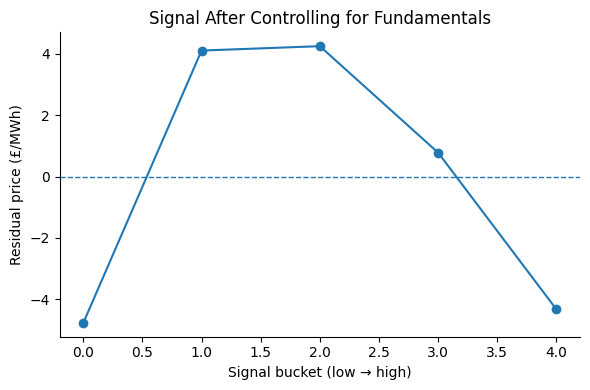

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.plot(
    bucket_means.index,
    bucket_means.values,
    marker='o'
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.xlabel("Signal bucket (low → high)")
plt.ylabel("Residual price (£/MWh)")
plt.title("Signal After Controlling for Fundamentals")

plt.grid(False)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

To isolate the incremental predictive power of the engineered signal, overnight prices were first residualised using the baseline regression model. This removes the effects of wind, demand, and seasonal controls.

The signal was then bucketed, and average residual prices were compared across buckets. This approach ensures that any remaining variation reflects signal-specific information rather than underlying system fundamentals.

## 11. Conclusion

This analysis identifies a statistically detectable relationship between evening BESS depletion and next-day overnight imbalance prices.

However, the effect is economically insufficient to support a viable trading strategy.

The results suggest that depletion is one component of price formation, but must be combined with additional system variables to generate actionable signals.

### Post-Hoc Market Interpretation (Outside Pre-Registered Scope)

The following section is not part of the pre-registered empirical test. It provides a structural interpretation of the null result and its implications for the GB battery market.

---

#### 1. Why the Mechanism Does Not Appear in Current Data

The absence of a measurable “overnight recharging footprint” suggests that, at present, battery behaviour is not a dominant driver of overnight prices. Instead, batteries appear to respond to system conditions and market incentives rather than shape them.

This is consistent with current market structure:

* **Day-Ahead optimisation:** A significant share of recharge activity is transacted in the Day-Ahead market, smoothing demand before it reaches intraday pricing
* **Duration constraints:** Most GB BESS assets are 1–2 hour systems, resulting in short, concentrated recharge windows rather than sustained overnight demand
* **Ancillary co-optimisation:** Many assets prioritise ancillary services (e.g. Dynamic Containment), remaining fully charged overnight rather than cycling energy

Together, these factors limit the extent to which evening depletion translates into observable overnight price pressure.

---

#### 2. Market Evolution: Capacity Expansion and Revenue Compression

The current profitability of ancillary services reflects a relative scarcity of flexible capacity. As new battery projects connect, this balance is likely to shift:

* **Premium compression:** Increased capacity may reduce ancillary service clearing prices
* **Operational rotation:** As ancillary revenues decline, a greater share of the fleet may shift toward wholesale energy arbitrage

This transition could increase the visibility of recharge-driven demand in overnight markets.

---

#### 3. Implications for Strategy

Paradoxically, the mechanism tested in this study may become more visible as the market evolves. However, the same capacity expansion that enables this effect is also likely to compress arbitrage spreads.

This creates a structural tension:

* Increased battery penetration → more observable system effects
* Increased competition → reduced monetisation potential

In this sense, the null result is informative. It suggests that while the underlying mechanism may strengthen over time, it may do so in a market environment where competition limits its economic value.

More broadly, the findings highlight a key feature of the current market: observable system dynamics do not necessarily translate into standalone trading opportunities.
